# Notebook 03 — Random Forest
  **Regression** → Predict WQI
  **Classification** → Predict Water Quality Category

  ### Why Random Forest?
  - Builds **many Decision Trees** (default 100) and combines their predictions
  - Each tree is trained on a **random subset of data** (bagging)
  - Each split considers only a **random subset of features**
  - These two randomness sources prevent any single tree from overfitting
  - Final answer = **average** (regression) or **majority vote** (classification)
  - Result: much lower variance, better generalization than a single tree

A Random Forest is an ensemble of decision trees, usually trained using the bagging method. Instead of building a BaggingClassifier with a DecisionTreeClassifier, you can use the RandomForestClassifier class, which is optimized for decision trees. Similarly, there is a RandomForestRegressor class for regression tasks.

The random forest algorithm introduces extra randomness when growing trees. Instead of searching for the best feature to split a node, it looks for the best feature among a random subset of features. By default, it samples a subset of features (controlled by the max_features parameter). This approach increases tree diversity, trading higher bias for lower variance, which generally results in a better overall model.

The following code trains a Random Forest classifier with 500 trees, each limited to a maximum of 16 leaf nodes, using all available CPU cores:

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
  r2_score, mean_squared_error, mean_absolute_error,
  accuracy_score, f1_score, classification_report, confusion_matrix
)


In [2]:
#Load Data
with open('processed_data.pkl', 'rb') as f:
  data = pickle.load(f)

X_train       = data['X_train']
X_test        = data['X_test']
y_reg_train   = data['y_reg_train']
y_reg_test    = data['y_reg_test']
y_clf_train   = data['y_clf_train']
y_clf_test    = data['y_clf_test']
le            = data['label_encoder']
feature_names = data['feature_names']

print("Train size:", X_train.shape)
print("Test  size:", X_test.shape)

Train size: (15223, 30)
Test  size: (3806, 30)


## Part 1 — Random Forest Regressor (Predict WQI)

Key parameters:
- `n_estimators` → number of trees (more = better but slower)
- `max_depth`    → depth of each tree (None = fully grown)
- `max_features` → features considered at each split ("sqrt" of total)

Unlike a single Decision Tree, Random Forest with full depth
does NOT overfit badly — randomness acts as a natural regularizer.

In [4]:
#(Train Random Forest Regressor)

rf_reg = RandomForestRegressor(
  n_estimators=100,
  random_state=42,
  n_jobs=-1         # use all CPU cores
)
rf_reg.fit(X_train, y_reg_train)

y_pred_train = rf_reg.predict(X_train)
y_pred_test  = rf_reg.predict(X_test)

r2_train = r2_score(y_reg_train, y_pred_train)
r2_test  = r2_score(y_reg_test,  y_pred_test)
rmse     = np.sqrt(mean_squared_error(y_reg_test, y_pred_test))
mae      = mean_absolute_error(y_reg_test, y_pred_test)

print("=== Random Forest Regressor ===")
print(f"R² Train : {r2_train:.4f}")
print(f"R² Test  : {r2_test:.4f}")
print(f"RMSE     : {rmse:.2f}")
print(f"MAE      : {mae:.2f}")



=== Random Forest Regressor ===
R² Train : 0.9990
R² Test  : 0.9957
RMSE     : 21.21
MAE      : 5.61


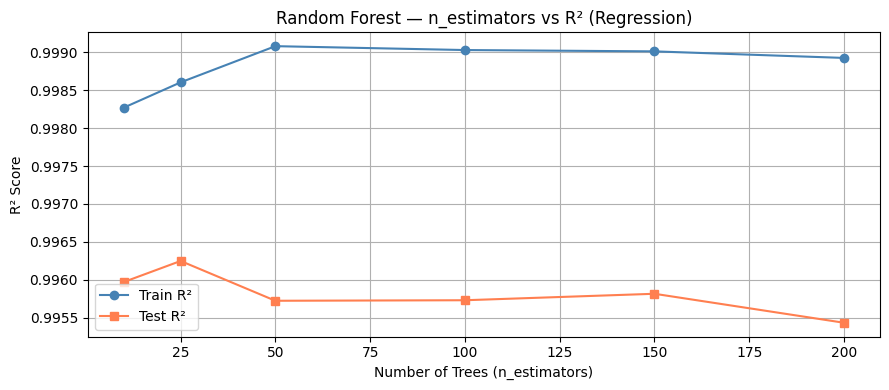

Key insight: after a certain point, adding more trees gives diminishing returns


In [7]:
#(Effect of n_estimators)

n_trees = [10, 25, 50, 100, 150, 200]
train_scores, test_scores = [], []

for n in n_trees:
  m = RandomForestRegressor(n_estimators=n, random_state=42, n_jobs=-1)
  m.fit(X_train, y_reg_train)
  train_scores.append(r2_score(y_reg_train, m.predict(X_train)))
  test_scores.append(r2_score(y_reg_test,   m.predict(X_test)))

plt.figure(figsize=(9, 4))
plt.plot(n_trees, train_scores, marker='o', label='Train R²', color='steelblue')
plt.plot(n_trees, test_scores,  marker='s', label='Test R²',  color='coral')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('R² Score')
plt.title('Random Forest — n_estimators vs R² (Regression)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
print("Key insight: after a certain point, adding more trees gives diminishing returns")


In [ ]:
# print feature importances
for score, name in zip(rnd_clf.feature_importances_, iris.data.columns):
    print(round(score, 2), name)

## Part 2 — Random Forest Classifier (Predict Water Quality)

In [8]:
#(Train Random Forest Classifier)

rf_clf = RandomForestClassifier(
  n_estimators=100,
  random_state=42,
  n_jobs=-1
)
rf_clf.fit(X_train, y_clf_train)

y_clf_pred_train = rf_clf.predict(X_train)
y_clf_pred_test  = rf_clf.predict(X_test)

acc_train = accuracy_score(y_clf_train, y_clf_pred_train)
acc_test  = accuracy_score(y_clf_test,  y_clf_pred_test)
f1_test   = f1_score(y_clf_test, y_clf_pred_test, average='weighted')

print("=== Random Forest Classifier ===")
print(f"Accuracy Train : {acc_train:.4f}")
print(f"Accuracy Test  : {acc_test:.4f}")
print(f"F1 Score Test  : {f1_test:.4f}")

=== Random Forest Classifier ===
Accuracy Train : 1.0000
Accuracy Test  : 0.9630
F1 Score Test  : 0.9629


In [10]:
#(Classification Report)

print("=== Detailed Classification Report ===")
print(classification_report(
  y_clf_test,
  y_clf_pred_test,
  target_names=le.classes_
))


=== Detailed Classification Report ===
                         precision    recall  f1-score   support

              Excellent       0.95      0.96      0.96       136
                   Good       0.95      0.92      0.94       317
                   Poor       0.97      0.97      0.97      1066
Unsuitable for Drinking       0.98      0.98      0.98      1370
Very Poor yet Drinkable       0.94      0.95      0.95       917

               accuracy                           0.96      3806
              macro avg       0.96      0.96      0.96      3806
           weighted avg       0.96      0.96      0.96      3806



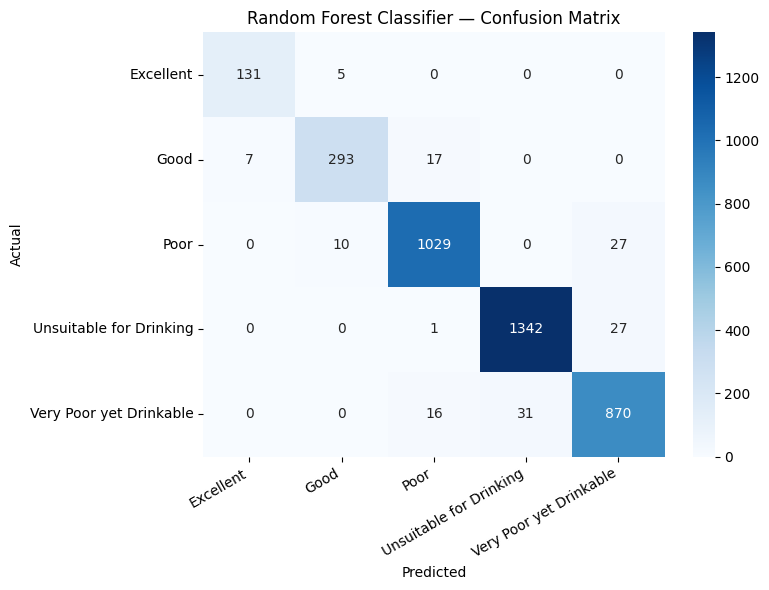

In [11]:
#(Confusion Matrix)

cm = confusion_matrix(y_clf_test, y_clf_pred_test)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
          xticklabels=le.classes_,
          yticklabels=le.classes_)
plt.title('Random Forest Classifier — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


## Feature Importance

Another great quality of random forests is that they make it easy to measure the relative importance of each feature. Scikit-Learn measures a feature’s importance by evaluating how much the tree nodes that use that feature reduce impurity on average across all trees in the forest. This is a weighted average, where each node’s weight is equal to the number of training samples associated with it. You can access the result using the feature_importances_ attribute.

=== Top 10 Feature Importances — Random Forest Regressor ===
 Feature  Importance
      EC    0.872746
     TDS    0.109238
      Cl    0.010885
      Na    0.002770
     NO3    0.000561
     SO4    0.000543
    HCO3    0.000535
       K    0.000492
Latitude    0.000402
      pH    0.000314


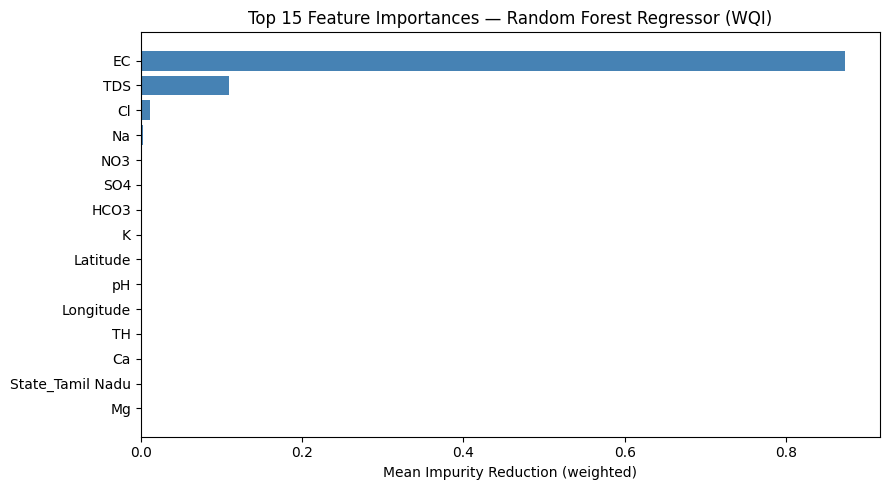

In [16]:
#(Feature Importance — Regressor)

importances_reg = rf_reg.feature_importances_
feat_imp_reg = pd.DataFrame({
  'Feature': feature_names,
  'Importance': importances_reg
}).sort_values('Importance', ascending=False)

print("=== Top 10 Feature Importances — Random Forest Regressor ===")
print(feat_imp_reg.head(10).to_string(index=False))

plt.figure(figsize=(9, 5))
plt.barh(feat_imp_reg['Feature'].head(15),
       feat_imp_reg['Importance'].head(15),
       color='steelblue')
plt.title('Top 15 Feature Importances — Random Forest Regressor (WQI)')
plt.xlabel('Mean Impurity Reduction (weighted)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


=== Top 10 Feature Importances — Random Forest Classifier ===
  Feature  Importance
      TDS    0.253315
       EC    0.251506
       Na    0.081439
       Cl    0.075785
       TH    0.072631
     HCO3    0.054393
       Mg    0.031863
      SO4    0.030348
       Ca    0.027684
Longitude    0.021983


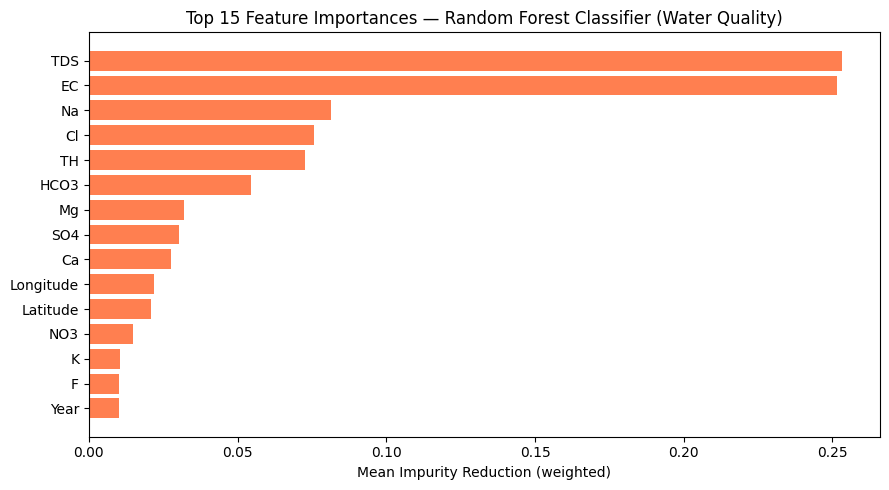

In [17]:
#(Feature Importance — Classifier)

importances_clf = rf_clf.feature_importances_
feat_imp_clf = pd.DataFrame({
  'Feature': feature_names,
  'Importance': importances_clf
}).sort_values('Importance', ascending=False)

print("=== Top 10 Feature Importances — Random Forest Classifier ===")
print(feat_imp_clf.head(10).to_string(index=False))

plt.figure(figsize=(9, 5))
plt.barh(feat_imp_clf['Feature'].head(15),
       feat_imp_clf['Importance'].head(15),
       color='coral')
plt.title('Top 15 Feature Importances — Random Forest Classifier (Water Quality)')
plt.xlabel('Mean Impurity Reduction (weighted)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


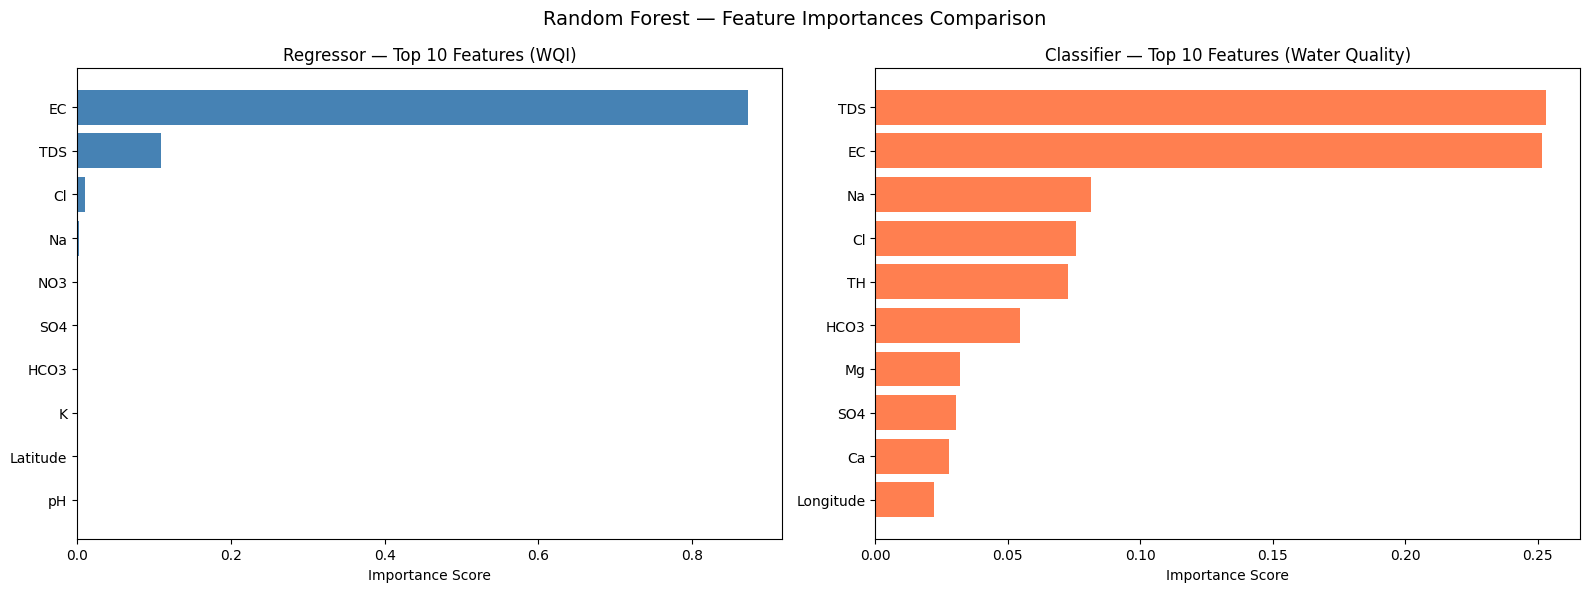

In [18]:
#(Side by Side Comparison)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Regressor importances
axes[0].barh(feat_imp_reg['Feature'].head(10),
           feat_imp_reg['Importance'].head(10),
           color='steelblue')
axes[0].set_title('Regressor — Top 10 Features (WQI)')
axes[0].set_xlabel('Importance Score')
axes[0].invert_yaxis()

# Classifier importances
axes[1].barh(feat_imp_clf['Feature'].head(10),
           feat_imp_clf['Importance'].head(10),
           color='coral')
axes[1].set_title('Classifier — Top 10 Features (Water Quality)')
axes[1].set_xlabel('Importance Score')
axes[1].invert_yaxis()

plt.suptitle('Random Forest — Feature Importances Comparison', fontsize=14)
plt.tight_layout()
plt.show()

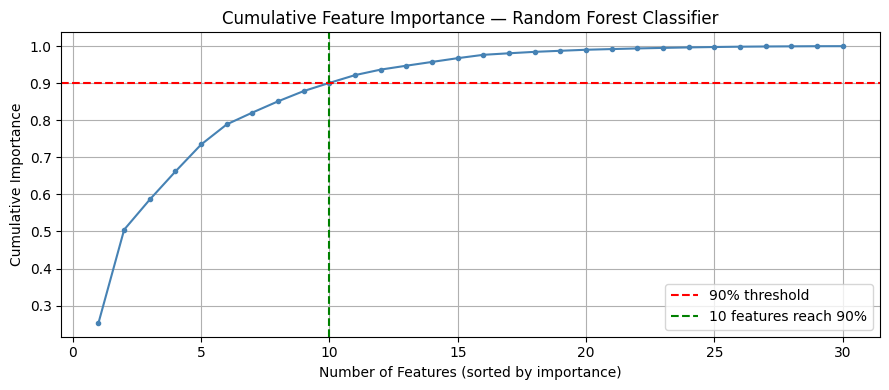

10 features out of 30 explain 90% of the model's decisions


In [21]:
#(Cumulative Importance)
# Help to determine how many features are actually needed — rest are mostly noise
# How many features cover 90% of total importance?
cumulative = feat_imp_clf['Importance'].cumsum()
n_features_90 = (cumulative < 0.90).sum() + 1

plt.figure(figsize=(9, 4))
plt.plot(range(1, len(cumulative) + 1), cumulative,
   marker='o', markersize=3, color='steelblue')
plt.axhline(y=0.90, color='red', linestyle='--', label='90% threshold')
plt.axvline(x=n_features_90, color='green', linestyle='--',
      label=f'{n_features_90} features reach 90%')
plt.xlabel('Number of Features (sorted by importance)')
plt.ylabel('Cumulative Importance')
plt.title('Cumulative Feature Importance — Random Forest Classifier')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"{n_features_90} features out of {len(feature_names)} explain 90% of the model's decisions")



In [22]:
#(Compare with Decision Tree)

with open('results_02_decision_tree.pkl', 'rb') as f:
  res_02 = pickle.load(f)

dt_r2   = round(res_02['Decision Tree Regression']['r2_test'],       4)
dt_rmse = round(res_02['Decision Tree Regression']['rmse'],           2)
dt_acc  = round(res_02['Decision Tree Classification']['acc_test'],   4)
dt_f1   = round(res_02['Decision Tree Classification']['f1_test'],    4)

summary = pd.DataFrame([
  {
      'Model': 'Decision Tree',
      'Task': 'Regression (WQI)',
      'R2 Test': dt_r2,
      'RMSE': dt_rmse,
      'Acc Test': '-',
      'F1 Test': '-'
  },
  {
      'Model': 'Random Forest',
      'Task': 'Regression (WQI)',
      'R2 Test': round(r2_test, 4),
      'R2 Test': round(r2_test, 4),
      'RMSE': round(rmse, 2),
      'Acc Test': '-',
      'F1 Test': '-'
  },
  {
      'Model': 'Decision Tree',
      'Task': 'Classification',
      'R2 Test': '-',
      'RMSE': '-',
      'Acc Test': dt_acc,
      'F1 Test': dt_f1
  },
  {
      'Model': 'Random Forest',
      'Task': 'Classification',
      'R2 Test': '-',
      'RMSE': '-',
      'Acc Test': round(acc_test, 4),
      'F1 Test': round(f1_test, 4)
  }
])

summary



,Model,Task,R2 Test,RMSE,Acc Test,F1 Test
0,Decision Tree,Regression (WQI),0.993,27.2,-,-
1,Random Forest,Regression (WQI),0.9957,21.21,-,-
2,Decision Tree,Classification,-,-,0.9569,0.957
3,Random Forest,Classification,-,-,0.963,0.9629


In [15]:
#(Save Results)

results = {
  'Random Forest Regression': {
      'r2_train': r2_train,
      'r2_test':  r2_test,
      'rmse':     rmse
  },
  'Random Forest Classification': {
      'acc_train': acc_train,
      'acc_test':  acc_test,
      'f1_test':   f1_test
  }
}

with open('results_03_random_forest.pkl', 'wb') as f:
  pickle.dump(results, f)

print("Saved. Move on to 04_XGBoost.ipynb")

Saved. Move on to 04_XGBoost.ipynb


  Key things to watch in this notebook:
  
  - Train vs Test gap — Random Forest should show a much smaller gap than Decision Tree
  - n_estimators curve — performance improves fast then plateaus (Cell 6)
  - Feature importance — compare top features with Decision Tree's top features — they should mostly
  agree
  - Classification score — expect this to beat or match Logistic Regression and Decision Tree